<a href="https://colab.research.google.com/github/deekshdechamma/NLP/blob/main/nlp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NLP Project 10: Banking Complaint Analysis
Problem Statement
A bank receives customer complaints related to transactions, loans, online banking services, and
account management through emails and support portals. Due to the high volume of complaints,
customer support teams find it difficult to manually review and categorize every issue quickly. The bank
wants to develop an NLP-based complaint analysis system that can identify common banking
problems, classify complaints, and help improve customer service efficiency.
Tasks
1. Collect banking complaint data.
2. Preprocess complaint text.
3. Categorize customer complaints.
4. Identify frequent banking issues.
5. Generate analytical report.

In [2]:
!pip install -q kagglehub nltk wordcloud scikit-learn

In [3]:
import pandas as pd
import numpy as np
import os
import re
import string
import matplotlib.pyplot as plt

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
import kagglehub

# Dataset URL:
# https://www.kaggle.com/datasets/selener/consumer-complaint-database

path = kagglehub.dataset_download(
    "selener/consumer-complaint-database"
)

print("Dataset location:", path)

100%|██████████| 176M/176M [00:01<00:00, 165MB/s]

Extracting files...


Dataset location: /root/.cache/kagglehub/datasets/selener/consumer-complaint-database/versions/1


In [5]:
files = os.listdir(path)

print(files)

['rows.csv']


In [6]:
csv_files = [
    file for file in files
    if file.lower().endswith('.csv')
]

print("CSV files:", csv_files)

CSV files: ['rows.csv']


In [7]:
file_path = os.path.join(
    path,
    csv_files[0]
)

df = pd.read_csv(
    file_path,
    low_memory=False
)

df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


In [8]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1282355, 18)

Columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Missing Values:
Date received                         0
Product                               0
Sub-product                      235166
Issue                                 0
Sub-issue                        531186
Consumer complaint narrative     898791
Company public response          833273
Company                               0
State                             19400
ZIP code                         115298
Tags                            1106712
Consumer consent provided?       591701
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response?  

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 18 columns):
 #   Column                        Non-Null Count    Dtype 
---  ------                        --------------    ----- 
 0   Date received                 1282355 non-null  object
 1   Product                       1282355 non-null  object
 2   Sub-product                   1047189 non-null  object
 3   Issue                         1282355 non-null  object
 4   Sub-issue                     751169 non-null   object
 5   Consumer complaint narrative  383564 non-null   object
 6   Company public response       449082 non-null   object
 7   Company                       1282355 non-null  object
 8   State                         1262955 non-null  object
 9   ZIP code                      1167057 non-null  object
 10  Tags                          175643 non-null   object
 11  Consumer consent provided?    690654 non-null   object
 12  Submitted via                 1282355 non-

In [10]:
complaint_col = 'Consumer complaint narrative'

print(
    df[complaint_col]
    .dropna()
    .head(10)
)

29904    The Summer of XX/XX/2018 I was denied a mortga...
30629    There are many mistakes appear in my report wi...
30735    There are many mistakes appear in my report wi...
30795    There are many mistakes appear in my report wi...
30807    There are many mistakes appear in my report wi...
30857    There are many mistakes appear in my report wi...
30977    There are many mistakes appear in my report wi...
31013    There are many mistakes appear in my report wi...
31078    There is an account reporting on my credit rep...
31458    The reason for my writing is to inform you tha...
Name: Consumer complaint narrative, dtype: object


In [11]:
df = df.dropna(
    subset=[complaint_col]
)

df = df.drop_duplicates(
    subset=[complaint_col]
)

df = df.reset_index(drop=True)

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (366945, 18)


In [12]:
if len(df) > 30000:
    df = df.sample(
        n=30000,
        random_state=42
    ).reset_index(drop=True)

print("Dataset used:", df.shape)

Dataset used: (30000, 18)


In [13]:
stop_words = set(
    stopwords.words('english')
)

lemmatizer = WordNetLemmatizer()

In [14]:
def preprocess_text(text):

    # lowercase
    text = str(text).lower()

    # remove URLs
    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )

    # remove masked information such as XXXX
    text = re.sub(
        r'x{2,}',
        '',
        text
    )

    # remove numbers
    text = re.sub(
        r'\d+',
        '',
        text
    )

    # remove punctuation
    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    # tokenization
    words = word_tokenize(text)

    # stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    return ' '.join(words)

In [15]:
df['Cleaned_Complaint'] = (
    df[complaint_col]
    .apply(preprocess_text)
)

In [19]:
df[
    [
        complaint_col,
        'Cleaned_Complaint'
    ]
].head(10)

,Consumer complaint narrative,Cleaned_Complaint
0,I live in the city of XXXX Maryland. The City ...,live city maryland city offer tax incentive ho...
1,My account balance on my capital one checking ...,account balance capital one checking account o...
2,multiple attempts to collect on a debt that ha...,multiple attempt collect debt charged mistakin...
3,I have informed Transunion that the Alabama XX...,informed transunion alabama account belong dif...
4,I pulled my credit report on XX/XX/2018 and no...,pulled credit report noticed collection accoun...
5,The letter from State Farm Bank alludes that I...,letter state farm bank alludes gave incorrect ...
6,I sent XXXX a letter of dispute regarding XXXX...,sent letter dispute regarding public record tr...
7,I filed a complaint with CFPB and Bank of Amer...,filed complaint cfpb bank amerca modified resp...
8,Re : XXXX XXXX XXXX ( AND ) XXXX XXXX Addition...,additional information add original complaint ...
9,I have noticed in the past that there were ( 2...,noticed past small student loan dated open app...


In [17]:
print(
    df['Product']
    .value_counts()
)

Product
Debt collection                                                                 6826
Credit reporting, credit repair services, or other personal consumer reports    6591
Mortgage                                                                        4338
Credit reporting                                                                2339
Student loan                                                                    1844
Credit card or prepaid card                                                     1743
Credit card                                                                     1549
Bank account or service                                                         1209
Checking or savings account                                                     1057
Consumer Loan                                                                    776
Vehicle loan or lease                                                            491
Money transfer, virtual currency, or money service       

In [18]:
df[
    [
        complaint_col,
        'Product'
    ]
].head(20)

,Consumer complaint narrative,Product
0,I live in the city of XXXX Maryland. The City ...,Mortgage
1,My account balance on my capital one checking ...,Checking or savings account
2,multiple attempts to collect on a debt that ha...,Debt collection
3,I have informed Transunion that the Alabama XX...,"Credit reporting, credit repair services, or o..."
4,I pulled my credit report on XX/XX/2018 and no...,Debt collection
5,The letter from State Farm Bank alludes that I...,Debt collection
6,I sent XXXX a letter of dispute regarding XXXX...,"Credit reporting, credit repair services, or o..."
7,I filed a complaint with CFPB and Bank of Amer...,Bank account or service
8,Re : XXXX XXXX XXXX ( AND ) XXXX XXXX Addition...,"Credit reporting, credit repair services, or o..."
9,I have noticed in the past that there were ( 2...,"Credit reporting, credit repair services, or o..."


In [20]:
def categorize_complaint(product):

    product = str(product).lower()

    if 'credit card' in product:
        return 'Credit Card'

    elif 'mortgage' in product:
        return 'Mortgage'

    elif 'student loan' in product:
        return 'Student Loan'

    elif 'vehicle loan' in product:
        return 'Vehicle Loan'

    elif 'payday loan' in product:
        return 'Other Loan'

    elif 'personal loan' in product:
        return 'Other Loan'

    elif 'consumer loan' in product:
        return 'Other Loan'

    elif 'checking' in product:
        return 'Bank Account'

    elif 'savings' in product:
        return 'Bank Account'

    elif 'bank account' in product:
        return 'Bank Account'

    elif 'money transfer' in product:
        return 'Money Transfer'

    elif 'debt collection' in product:
        return 'Debt Collection'

    elif 'credit reporting' in product:
        return 'Credit Reporting'

    else:
        return 'Other'

In [21]:
df['Complaint_Category'] = (
    df['Product']
    .apply(categorize_complaint)
)


In [22]:
df[
    [
        'Product',
        'Complaint_Category'
    ]
].head(20)

,Product,Complaint_Category
0,Mortgage,Mortgage
1,Checking or savings account,Bank Account
2,Debt collection,Debt Collection
3,"Credit reporting, credit repair services, or o...",Credit Reporting
4,Debt collection,Debt Collection
5,Debt collection,Debt Collection
6,"Credit reporting, credit repair services, or o...",Credit Reporting
7,Bank account or service,Bank Account
8,"Credit reporting, credit repair services, or o...",Credit Reporting
9,"Credit reporting, credit repair services, or o...",Credit Reporting


In [23]:
category_counts = (
    df['Complaint_Category']
    .value_counts()
)

print(category_counts)

Complaint_Category
Credit Reporting    8930
Debt Collection     6826
Mortgage            4338
Credit Card         3292
Bank Account        2266
Student Loan        1844
Other Loan          1274
Money Transfer       598
Vehicle Loan         491
Other                141
Name: count, dtype: int64


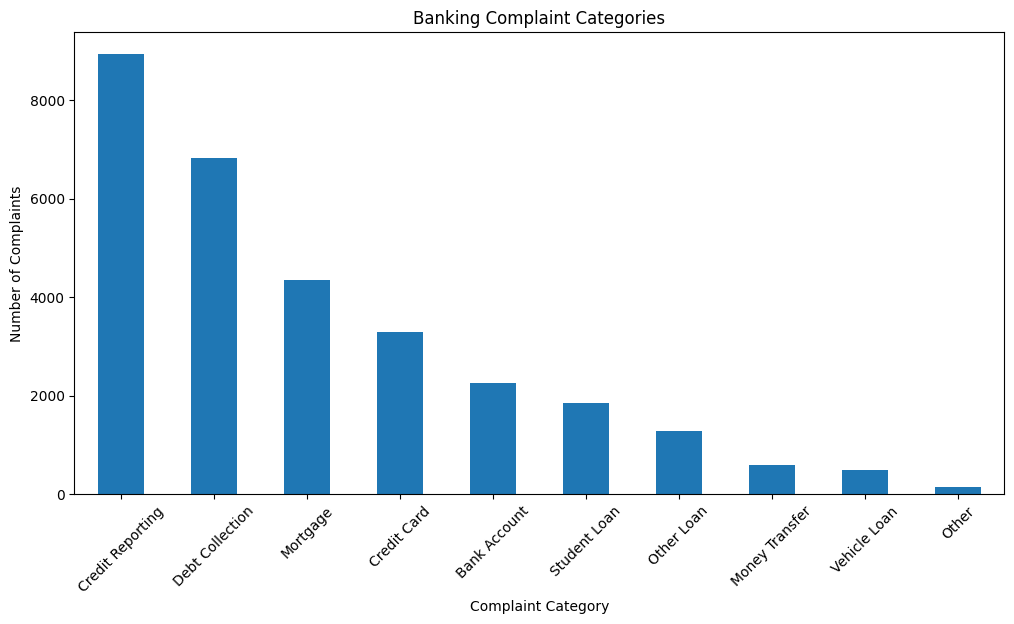

In [24]:
plt.figure(figsize=(12, 6))

category_counts.plot(
    kind='bar'
)

plt.title(
    'Banking Complaint Categories'
)

plt.xlabel(
    'Complaint Category'
)

plt.ylabel(
    'Number of Complaints'
)

plt.xticks(
    rotation=45
)

plt.show()

In [25]:
print(
    df['Issue']
    .value_counts()
    .head(20)
)

Issue
Incorrect information on your report                                                3367
Problem with a credit reporting company's investigation into an existing problem    1890
Incorrect information on credit report                                              1555
Attempts to collect debt not owed                                                   1483
Cont'd attempts collect debt not owed                                               1336
Loan servicing, payments, escrow account                                            1193
Improper use of your report                                                         1066
Communication tactics                                                                911
Loan modification,collection,foreclosure                                             882
Trouble during payment process                                                       752
False statements or representation                                                   715
Written notific

In [26]:
top_issues = (
    df['Issue']
    .value_counts()
    .head(10)
)

top_issues

,count
Issue,
Incorrect information on your report,3367
Problem with a credit reporting company's investigation into an existing problem,1890
Incorrect information on credit report,1555
Attempts to collect debt not owed,1483
Cont'd attempts collect debt not owed,1336
"Loan servicing, payments, escrow account",1193
Improper use of your report,1066
Communication tactics,911
"Loan modification,collection,foreclosure",882


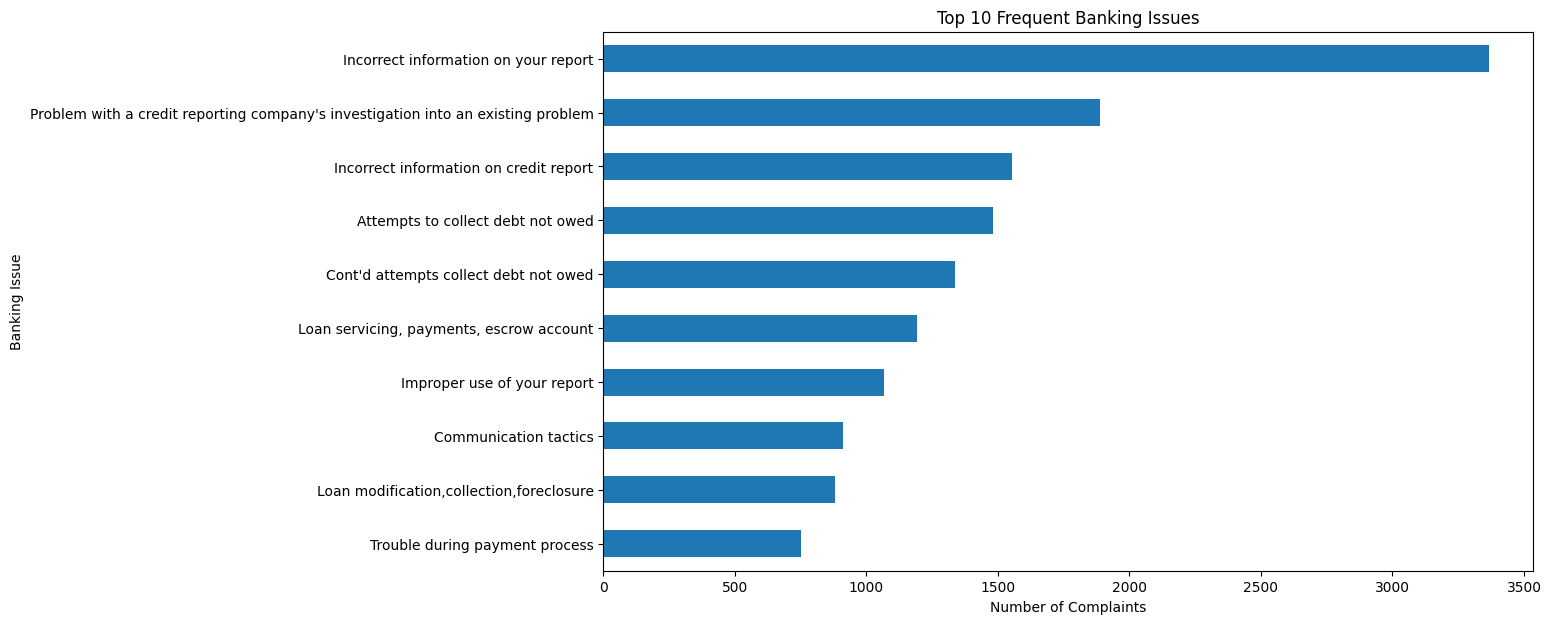

In [27]:
plt.figure(figsize=(12, 7))

top_issues.sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 10 Frequent Banking Issues'
)

plt.xlabel(
    'Number of Complaints'
)

plt.ylabel(
    'Banking Issue'
)

plt.show()

In [28]:
all_words = ' '.join(
    df['Cleaned_Complaint']
).split()

word_counts = Counter(
    all_words
)

common_words = (
    word_counts
    .most_common(20)
)

common_words

[('account', 46079),
 ('credit', 45806),
 ('payment', 32319),
 ('loan', 25165),
 ('report', 21745),
 ('would', 21443),
 ('time', 18421),
 ('information', 18043),
 ('debt', 17357),
 ('bank', 16892),
 ('told', 16291),
 ('company', 16111),
 ('received', 15156),
 ('card', 14587),
 ('call', 14142),
 ('day', 13762),
 ('letter', 13347),
 ('called', 13318),
 ('month', 12343),
 ('never', 12273)]

In [29]:
common_words_df = pd.DataFrame(
    common_words,
    columns=[
        'Word',
        'Frequency'
    ]
)

common_words_df

,Word,Frequency
0,account,46079
1,credit,45806
2,payment,32319
3,loan,25165
4,report,21745
5,would,21443
6,time,18421
7,information,18043
8,debt,17357
9,bank,16892


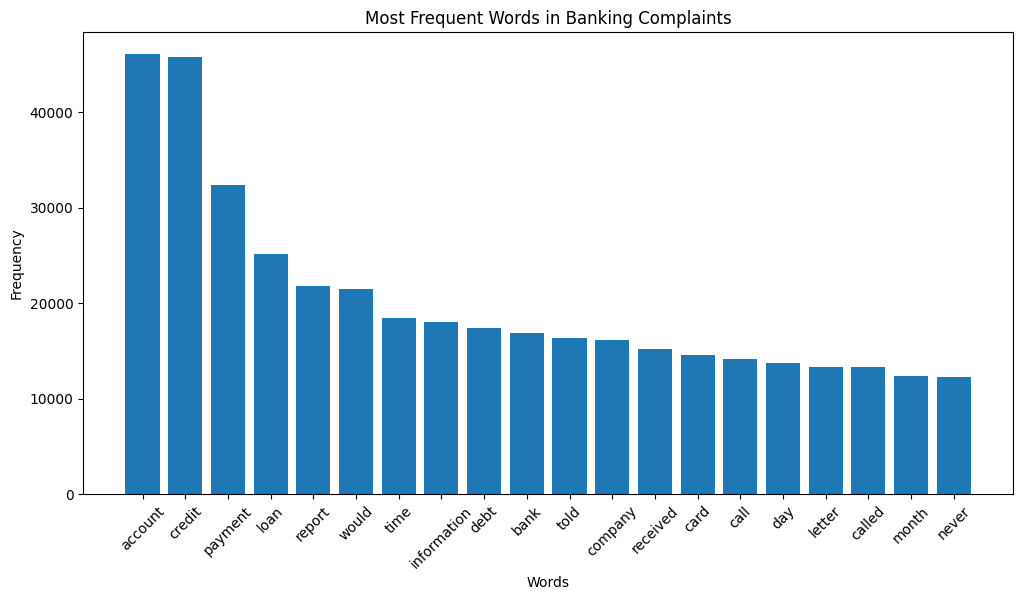

In [30]:
plt.figure(figsize=(12, 6))

plt.bar(
    common_words_df['Word'],
    common_words_df['Frequency']
)

plt.title(
    'Most Frequent Words in Banking Complaints'
)

plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(
    rotation=45
)

plt.show()

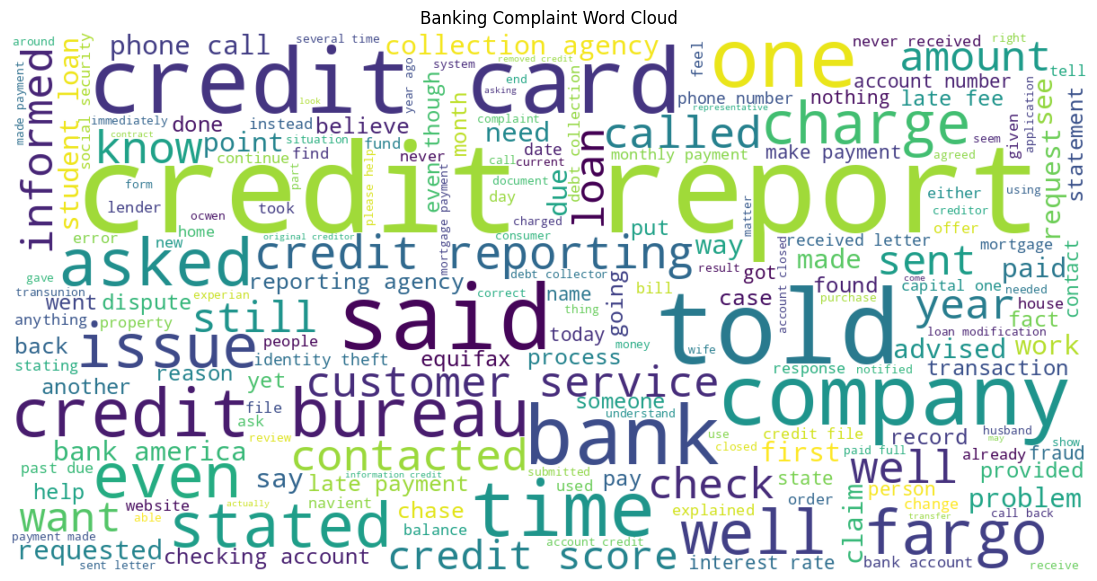

In [31]:
complaint_text = ' '.join(
    df['Cleaned_Complaint']
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(
    complaint_text
)

plt.figure(
    figsize=(14, 7)
)

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title(
    'Banking Complaint Word Cloud'
)

plt.show()

In [32]:
category_issue = pd.crosstab(
    df['Complaint_Category'],
    df['Issue']
)

category_issue

Issue,APR or interest rate,"Account opening, closing, or management",Account terms and changes,Adding money,Advertising,Advertising and marketing,"Advertising and marketing, including promotional offers","Advertising, marketing or disclosures",Application processing delay,"Application, originator, mortgage broker",...,Unexpected or other fees,Unexpected/Other fees,Unsolicited issuance of credit card,Using a debit or ATM card,Vehicle was damaged or destroyed the vehicle,Vehicle was repossessed or sold the vehicle,"Was approved for a loan, but didn't receive money","Was approved for a loan, but didn't receive the money",Written notification about debt,Wrong amount charged or received
Complaint_Category,,,,,,,,,,,,,,,,,,,,,
Bank Account,0,496,0,0,0,0,0,0,0,0,...,0,0,0,123,0,0,0,0,0,0
Credit Card,77,0,0,0,9,78,156,0,10,0,...,22,0,39,0,0,0,0,0,0,0
Credit Reporting,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
Debt Collection,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,698,0
Money Transfer,0,0,0,0,0,0,0,0,0,0,...,15,0,0,0,0,0,0,0,0,23
Mortgage,0,0,0,0,0,0,0,0,0,332,...,0,0,0,0,0,0,0,0,0,0
Other,0,0,0,10,0,1,0,5,0,0,...,0,3,0,0,0,0,0,0,0,0
Other Loan,0,0,4,0,0,0,0,0,0,0,...,0,0,0,0,3,3,1,3,0,0
Student Loan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
print("MAJOR ISSUE BY BANKING CATEGORY")
print("=" * 60)

for category in df['Complaint_Category'].unique():

    temp = df[
        df['Complaint_Category'] == category
    ]

    if len(temp) > 0:

        major_issue = (
            temp['Issue']
            .value_counts()
            .index[0]
        )

        count = (
            temp['Issue']
            .value_counts()
            .iloc[0]
        )

        print(
            f"{category}: "
            f"{major_issue} "
            f"({count} complaints)"
        )

MAJOR ISSUE BY BANKING CATEGORY
Mortgage: Loan servicing, payments, escrow account (1193 complaints)
Bank Account: Managing an account (570 complaints)
Debt Collection: Attempts to collect debt not owed (1483 complaints)
Credit Reporting: Incorrect information on your report (3199 complaints)
Credit Card: Problem with a purchase shown on your statement (378 complaints)
Other Loan: Managing the loan or lease (334 complaints)
Student Loan: Dealing with my lender or servicer (676 complaints)
Money Transfer: Fraud or scam (165 complaints)
Vehicle Loan: Managing the loan or lease (179 complaints)
Other: Unauthorized transactions/trans. issues (55 complaints)


In [34]:
total_complaints = len(df)

major_category = (
    category_counts
    .idxmax()
)

major_category_count = (
    category_counts
    .max()
)

major_issue = (
    df['Issue']
    .value_counts()
    .idxmax()
)

major_issue_count = (
    df['Issue']
    .value_counts()
    .max()
)

In [35]:
print("=" * 60)
print("BANKING COMPLAINT ANALYSIS REPORT")
print("=" * 60)

print(
    "\nTotal Complaints Analyzed:",
    total_complaints
)

print(
    "\nMost Common Complaint Category:",
    major_category
)

print(
    "Number of Complaints:",
    major_category_count
)

print(
    "\nMost Frequent Banking Issue:",
    major_issue
)

print(
    "Number of Complaints:",
    major_issue_count
)

print("\nTOP 5 COMPLAINT CATEGORIES")
print("-" * 40)

print(
    category_counts.head(5)
)

print("\nTOP 5 BANKING ISSUES")
print("-" * 40)

print(
    df['Issue']
    .value_counts()
    .head(5)
)

BANKING COMPLAINT ANALYSIS REPORT

Total Complaints Analyzed: 30000

Most Common Complaint Category: Credit Reporting
Number of Complaints: 8930

Most Frequent Banking Issue: Incorrect information on your report
Number of Complaints: 3367

TOP 5 COMPLAINT CATEGORIES
----------------------------------------
Complaint_Category
Credit Reporting    8930
Debt Collection     6826
Mortgage            4338
Credit Card         3292
Bank Account        2266
Name: count, dtype: int64

TOP 5 BANKING ISSUES
----------------------------------------
Issue
Incorrect information on your report                                                3367
Problem with a credit reporting company's investigation into an existing problem    1890
Incorrect information on credit report                                              1555
Attempts to collect debt not owed                                                   1483
Cont'd attempts collect debt not owed                                               1336
Name: co

In [36]:
print("\n" + "=" * 60)
print("CUSTOMER SERVICE RECOMMENDATION")
print("=" * 60)

print(
    f"""
The complaint analysis shows that
'{major_category}' is one of the major areas
generating customer complaints.

The most frequently reported issue is:
'{major_issue}'.

The bank should prioritize this issue,
investigate its root causes, improve customer
support procedures, and provide faster complaint
resolution.

Automating complaint categorization using NLP
can also help customer support teams route
complaints to the correct department more
efficiently.
"""
)


CUSTOMER SERVICE RECOMMENDATION

The complaint analysis shows that
'Credit Reporting' is one of the major areas
generating customer complaints.

The most frequently reported issue is:
'Incorrect information on your report'.

The bank should prioritize this issue,
investigate its root causes, improve customer
support procedures, and provide faster complaint
resolution.

Automating complaint categorization using NLP
can also help customer support teams route
complaints to the correct department more
efficiently.



In [37]:
output_columns = [
    complaint_col,
    'Cleaned_Complaint',
    'Product',
    'Complaint_Category',
    'Issue'
]

df[
    output_columns
].to_csv(
    'Banking_Complaint_Analysis.csv',
    index=False
)

print(
    "Banking complaint analysis saved successfully."
)

Banking complaint analysis saved successfully.
